In [7]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import torch
import torch.nn as nn

In [8]:
tf.random.set_seed(7)

In [9]:
dataframe = pd.read_csv('https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv', usecols=[1], engine='python')
df = dataframe.values
df = df.astype('float32')
plt.plot(df)
plt.show()

URLError: <urlopen error [Errno 11001] getaddrinfo failed>

In [ ]:
scaler = MinMaxScaler(feature_range=(0,1))
df = scaler.fit_transform(df)
df[: 5]
df.shape

(144, 1)

In [ ]:
train_size = int(len(df) * 0.67)
test_size = len(df) - train_size

train, test = df[0:train_size, :], df[train_size:len(df), :]
print(type(train), len(test))

<class 'numpy.ndarray'> 48


In [ ]:
look_back = 1 
def create_dataset(dataset, look_back=1):
    dataX, dataY = [], []
    for i in range(len(dataset) - look_back - 1):
        dataX.append(dataset[i:(i + look_back), 0])
        dataY.append(dataset[i + look_back, 0])
    return np.array(dataX), np.array(dataY)

trainX, trainY = create_dataset(dataset=train, look_back=look_back)
testX, testY = create_dataset(test, look_back=look_back)


In [ ]:
trainX = trainX.reshape(94,1)
testX = testX.reshape(46,1)
trainY = trainY.reshape(94)
testY = testY.reshape(46)

n=100, depth=1, lr=0.1 -> acc=0.0245
n=100, depth=1, lr=0.5 -> acc=0.0241
n=100, depth=1, lr=0.6 -> acc=0.0236
n=100, depth=1, lr=0.7 -> acc=0.0237
n=100, depth=1, lr=0.9 -> acc=0.0238
n=100, depth=1, lr=1 -> acc=0.0235
n=100, depth=2, lr=0.1 -> acc=0.0248
n=100, depth=2, lr=0.5 -> acc=0.0235
n=100, depth=2, lr=0.6 -> acc=0.0236
n=100, depth=2, lr=0.7 -> acc=0.0236
n=100, depth=2, lr=0.9 -> acc=0.0234
n=100, depth=2, lr=1 -> acc=0.0235
n=130, depth=1, lr=0.1 -> acc=0.0241
n=130, depth=1, lr=0.5 -> acc=0.0236
n=130, depth=1, lr=0.6 -> acc=0.0231
n=130, depth=1, lr=0.7 -> acc=0.0238
n=130, depth=1, lr=0.9 -> acc=0.0239
n=130, depth=1, lr=1 -> acc=0.0238
n=130, depth=2, lr=0.1 -> acc=0.0243
n=130, depth=2, lr=0.5 -> acc=0.0236
n=130, depth=2, lr=0.6 -> acc=0.0235
n=130, depth=2, lr=0.7 -> acc=0.0235
n=130, depth=2, lr=0.9 -> acc=0.0234
n=130, depth=2, lr=1 -> acc=0.0235
n=140, depth=1, lr=0.1 -> acc=0.0241
n=140, depth=1, lr=0.5 -> acc=0.0236
n=140, depth=1, lr=0.6 -> acc=0.0233
n=140, de

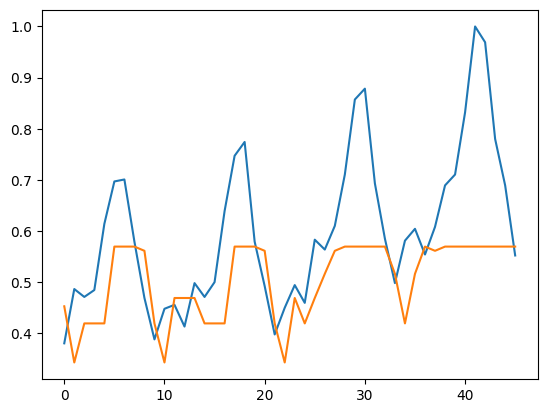

In [ ]:
from xgboost import XGBRegressor
from itertools import product

param_grid = {
    "n_estimators": [100, 130, 140, 150],
    "max_depth": [1, 2],
    "learning_rate": [0.1, 0.5, 0.6, 0.7, 0.9, 1],
} 

best_acc = 10000000
best_param = {}

for n, d, lr in product(param_grid["n_estimators"], param_grid["max_depth"], param_grid["learning_rate"]):
    model = XGBRegressor(n_estimators=n, max_depth=d, learning_rate=lr,random_state= 42)
    model.fit(trainX, trainY)
    pred = model.predict(testX)

    acc = mean_squared_error(testY, pred)

    if acc < best_acc:
        best_acc = acc
        best_param = {"n_estimators": n, "max_depth": d, "learning_rate": lr}
    print(f"n={n}, depth={d}, lr={lr} -> acc={acc:.4f}")
print(f"\nBest: {best_param}, Accuracy: {best_acc:.4f}")

model = XGBRegressor(n_estimators=best_param["n_estimators"], max_depth=best_param["max_depth"], learning_rate=best_param["learning_rate"], random_state=42)
model.fit(trainX, trainY )
predictions= model.predict(testX)

plt.plot(testY)
plt.plot(predictions)
plt.show()

In [ ]:
import os
import joblib

os.makedirs("models/", exist_ok=True)

joblib.dump(model, "src/models/xgb_v1.pkl")



['src/models/xgb_v1.pkl']

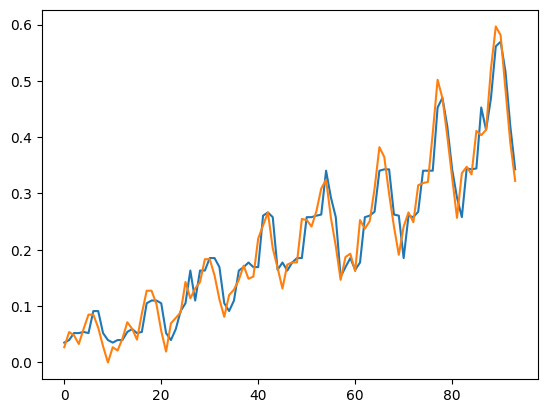

In [ ]:
m_v1 = joblib.load("src/models/xgb_v1.pkl")
p = m_v1.predict(trainX)

plt.plot(p)
plt.plot(trainY)
plt.show()

In [ ]:
# reshape input to be [samples, time steps, features]
trainX = np.reshape(trainX, (trainX.shape[0], 1, trainX.shape[1]))
testX = np.reshape(testX, (testX.shape[0], 1, testX.shape[1]))

In [ ]:
# create and fit the LSTM network
model = Sequential()
model.add(LSTM(4, input_shape=(1, look_back)))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(trainX, trainY, epochs=100, batch_size=1, verbose=2)

c:\Users\sou1n\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
94/94 - 3s - 28ms/step - loss: 0.0482
Epoch 2/100
94/94 - 0s - 3ms/step - loss: 0.0243
Epoch 3/100
94/94 - 0s - 3ms/step - loss: 0.0183
Epoch 4/100
94/94 - 0s - 3ms/step - loss: 0.0166
Epoch 5/100
94/94 - 0s - 3ms/step - loss: 0.0156
Epoch 6/100
94/94 - 0s - 3ms/step - loss: 0.0146
Epoch 7/100
94/94 - 0s - 2ms/step - loss: 0.0137
Epoch 8/100
94/94 - 0s - 3ms/step - loss: 0.0128
Epoch 9/100
94/94 - 0s - 3ms/step - loss: 0.0118
Epoch 10/100
94/94 - 0s - 3ms/step - loss: 0.0109
Epoch 11/100
94/94 - 0s - 3ms/step - loss: 0.0100
Epoch 12/100
94/94 - 0s - 3ms/step - loss: 0.0090
Epoch 13/100
94/94 - 0s - 2ms/step - loss: 0.0081
Epoch 14/100
94/94 - 0s - 2ms/step - loss: 0.0073
Epoch 15/100
94/94 - 0s - 3ms/step - loss: 0.0064
Epoch 16/100
94/94 - 0s - 2ms/step - loss: 0.0057
Epoch 17/100
94/94 - 0s - 2ms/step - loss: 0.0050
Epoch 18/100
94/94 - 0s - 2ms/step - loss: 0.0044
Epoch 19/100
94/94 - 0s - 2ms/step - loss: 0.0038
Epoch 20/100
94/94 - 0s - 2ms/step - loss: 0.0034
Epoch 21

In [ ]:
# make predictions
trainPredict = model.predict(trainX)
testPredict = model.predict(testX)
# invert predictions
trainPredict = scaler.inverse_transform(trainPredict)
trainY = scaler.inverse_transform([trainY])
testPredict = scaler.inverse_transform(testPredict)
testY = scaler.inverse_transform([testY])
# calculate root mean squared error
trainScore = np.sqrt(mean_squared_error(trainY[0], trainPredict[:,0]))
print('Train Score: %.2f RMSE' % (trainScore))
testScore = np.sqrt(mean_squared_error(testY[0], testPredict[:,0]))
print('Test Score: %.2f RMSE' % (testScore))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
Train Score: 22.78 RMSE
Test Score: 49.49 RMSE


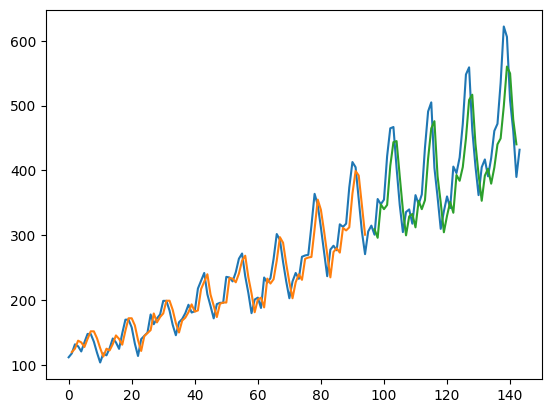

In [ ]:
# shift train predictions for plotting
trainPredictPlot = np.empty_like(df)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(trainPredict)+look_back, :] = trainPredict
# shift test predictions for plotting
testPredictPlot = np.empty_like(df)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(trainPredict)+(look_back*2)+1:len(df)-1, :] = testPredict
# plot baseline and predictions
plt.plot(scaler.inverse_transform(df))
plt.plot(trainPredictPlot)
plt.plot(testPredictPlot)
plt.show()

In [ ]:
x = np.linspace(0, 100, 1000)
data = np.sin(x)
data.shape

(1000,)

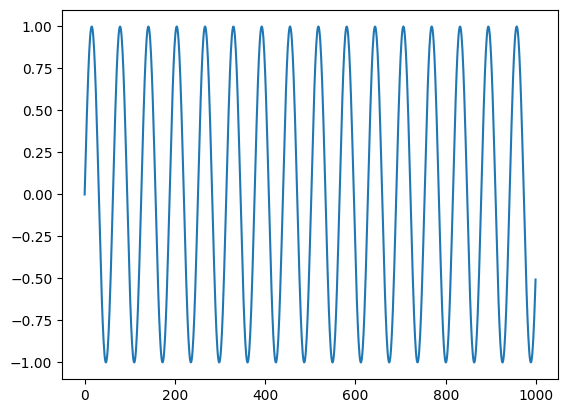

In [ ]:
plt.plot(data)
plt.show()

In [ ]:
def create_sequences(data, seq_len):
    x = []
    y = []
    length = len(data)

    for i in range(length-seq_len):
        x.append(data[i: i+seq_len])
        y.append(data[i+seq_len])

    x = np.array(x)
    y = np.array(y)

    x = x.reshape(x.shape[0], x.shape[1], 1)
    y = y.reshape(x.shape[0], 1)
    return x, y 


In [ ]:
x_train, y_train = create_sequences(data, 30)

In [ ]:
class SimpleLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=32, batch_first=True)
        self.linear = nn.Linear(32, 1)
    
    def forward(self, x):
        output, (hidden, cell) = self.lstm(x)

        last = output[:, -1, :]
        pred = self.linear(last)

        return pred


In [ ]:
x_train = torch.FloatTensor(x_train)
y_train = torch.FloatTensor(y_train)


In [ ]:
y_train.shape

torch.Size([970, 1])

In [ ]:
model = SimpleLSTM()
criteria = nn.MSELoss()
optimizer = torch.optim.Adam( model.parameters(), lr= 0.001 )

for epoch in range(100):

    optimizer.zero_grad()

    predictions = model(x_train)

    loss = criteria(predictions, y_train)

    loss.backward()

    optimizer.step()

    if epoch % 10 == 0:
        print(f"epoch {epoch} loss = {loss.item()}")


epoch 0 loss = 0.5047804713249207
epoch 10 loss = 0.4319089949131012
epoch 20 loss = 0.3596755564212799
epoch 30 loss = 0.27018246054649353
epoch 40 loss = 0.16508495807647705
epoch 50 loss = 0.09911685436964035
epoch 60 loss = 0.03738502040505409
epoch 70 loss = 0.007508598268032074
epoch 80 loss = 0.006180393509566784
epoch 90 loss = 0.004644625820219517


In [ ]:
model.eval()

SimpleLSTM(
  (lstm): LSTM(1, 32, batch_first=True)
  (linear): Linear(in_features=32, out_features=1, bias=True)
)

In [ ]:
with torch.no_grad():
    predictions = model(x_train)


In [ ]:
predictions = predictions.numpy()
actual = y_train.numpy()

predictions.shape

(970, 1)

In [ ]:
actual.shape

(970, 1)

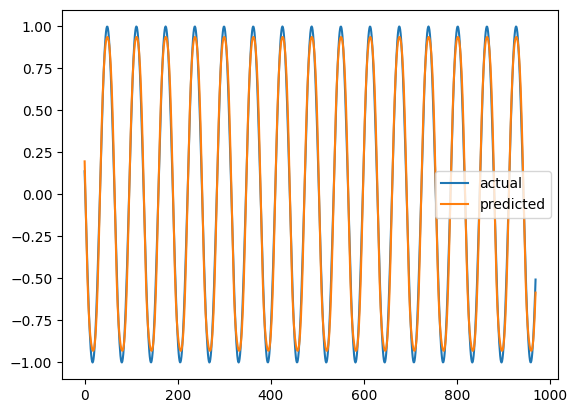

In [ ]:
plt.plot(actual, label = "actual")
plt.plot(predictions, label= "predicted")
plt.legend()
plt.show()


In [10]:
np.random.seed(42)
actual_returns = np.random.normal(0.001, 0.02, 100)  # 100 days of fake returns
predicted_returns = actual_returns + np.random.normal(0, 0.01, 100)  # noisy predictions

In [23]:
def strategy_returns(actual, predicted):
    remaining = []

    for a, p in zip(actual, predicted):
        if np.sign(a) == np.sign(p):
            remaining.append(abs(p))

        else:
            remaining.append(-abs(p))

    return remaining


In [24]:
portfolio = [10000]
strat = strategy_returns(actual_returns, predicted_returns)
print(strat[:5])
for s in strat:
    portfolio.append(portfolio[-1] * (1 + s))


[np.float64(-0.0032194243602794888), np.float64(0.005971739251077283), np.float64(0.010526625596746154), np.float64(0.02343782443594432), np.float64(0.005295924611126811)]


In [25]:
def sharpie(strat_ret, risk_free= 0.0):
    excess = np.array(strat_ret) - risk_free
    if np.std(excess) == 0:
        return 0.0
    
    return (np.mean(excess) / np.std(excess)) * np.sqrt(252)

sharpie(strat)

np.float64(15.93686086432436)

In [26]:
def max_drawdown(portf):
    peak = portf[0]
    max_dd = 0

    for i in portf:
        if i > peak:
            peak = i
        dd = (peak - i) / peak
        if dd > max_dd:
            max_dd = dd

    return max_dd

max_drawdown(portfolio)

np.float64(0.009892981632019602)

Text(0, 0.5, 'value $')

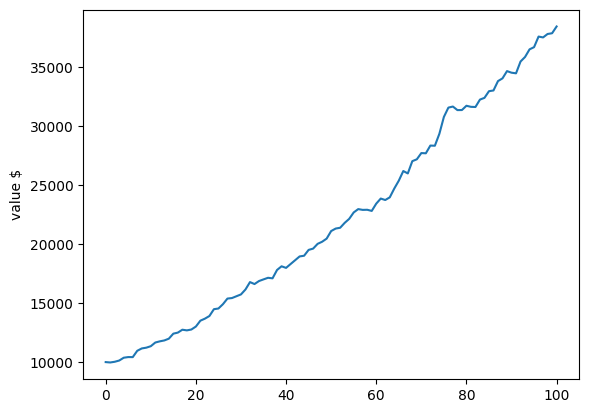

In [27]:
plt.plot(portfolio)
plt.ylabel("value $")